In [3]:
import pandas as pd
import re
import html
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder # <--- HERRAMIENTA NUEVA

# Cargar modelo de lenguaje de spacy
nlp = spacy.load('en_core_web_sm')

# Carga de los datasets
df_train = pd.read_csv('../data/ag_news_train.csv')
df_test = pd.read_csv('../data/ag_news_test.csv')

# CORRECCIÓN: Transformamos las etiquetas de texto a números (0, 1, 2, 3)
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['label'])
df_test['label'] = le.transform(df_test['label'])

# Guardamos los nombres reales para usarlos en la matriz de confusión luego
class_names = le.classes_ 

print(f"Dimensiones Train: {df_train.shape}")
print(f"Dimensiones Test: {df_test.shape}")

Dimensiones Train: (8000, 2)
Dimensiones Test: (2000, 2)


In [4]:
def preprocess_text(text: str) -> str:
    # 1. Decodificar entidades HTML
    text = html.unescape(str(text))
    
    # 2. Limpieza estructural
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\b(href|target|font|face|size|color|align|lt|gt|quickinfo|fullquote)\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    
    # 3. Lematización y Stop-words
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_punct and not token.is_stop]
    return " ".join(tokens)

# APLICAR LIMPIEZA (Esto puede tardar unos minutos al procesar miles de filas)
print("Limpiando Train set...")
df_train['text_clean'] = df_train['text'].apply(preprocess_text)

print("Limpiando Test set...")
df_test['text_clean'] = df_test['text'].apply(preprocess_text)

Limpiando Train set...
Limpiando Test set...


In [5]:
# Instanciamos el vectorizador limitando características y usando bigramas
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# IMPORTANTE: fit_transform SOLO en Train. Transform en Test.
print("Vectorizando textos...")
X_train = tfidf.fit_transform(df_train['text_clean'])
X_test = tfidf.transform(df_test['text_clean'])

y_train = df_train['label']
y_test = df_test['label']

print(f"Forma de la matriz de entrenamiento: {X_train.shape}")

Vectorizando textos...
Forma de la matriz de entrenamiento: (8000, 10000)


Entrenando Regresión Logística...

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

    Business       0.85      0.86      0.85       500
    Sci_Tech       0.87      0.86      0.87       500
      Sports       0.94      0.96      0.95       500
       World       0.90      0.89      0.90       500

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



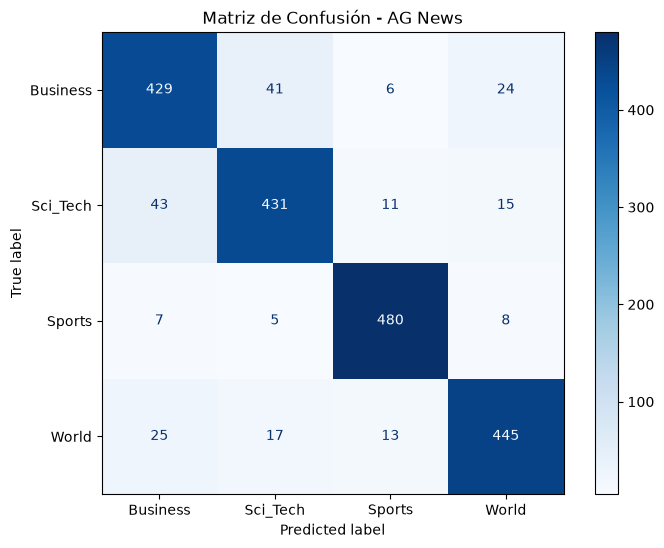

In [6]:
# Elegimos Logistic Regression como baseline por su velocidad y buen manejo de matrices esparsas
print("Entrenando Regresión Logística...")
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)

# Reporte de Métricas
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - AG News')
plt.show()